In [1]:
from b_chromatic_trees import *
from b_chromatic_utils import *
from timeit import default_timer as timer
import pickle

### Testing which technique is more memory efficient to store the datasets

Writing the trees in one file opening it once

In [9]:
with open("saving_trees_1.example", "w") as f:
    for _ in range(500):
        for n in range(200, 10000, 200):
            Ti = random_recursive_tree(n)
            f.write("{} {}\n".format(len(Ti.nodes()), len(Ti.edges())))
            for u, v in Ti.edges():
                f.write("{} {}\n".format(u, v))

Writing the trees in one file openning every time a tree is generated

In [10]:
for _ in range(500):
    for n in range(200, 10000, 200):
        with open("saving_trees_2.example", "a") as f:
            Ti = random_recursive_tree(n)
            f.write("{} {}\n".format(len(Ti.nodes()), len(Ti.edges())))
            for u, v in Ti.edges():
                f.write("{} {}\n".format(u, v))

Writing the trees in one pickle file generating first all the trees and then writing it down

In [11]:
graphs_list = {}
for n in range(200, 10000, 200):
    graphs_list[n] = []
    for i in range(100):
        Ti = random_recursive_tree(n)
        graphs_list[n].append(Ti)
store_graphs_as_list_of_dicts("saving_trees_pickle.example", graphs_list)

KeyboardInterrupt: 

### Testing how much time consuming is each function to generated the trees

Recursive trees

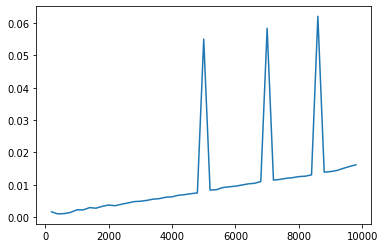

In [5]:
import matplotlib.pyplot as plt
times_1 = []
n_vertices_list = range(200, 10000, 200)
for n in n_vertices_list:
    t = timer()
    Ti = random_recursive_tree(n)
    times_1.append(timer()-t)
fig, ax = plt.subplots(1)
ax.plot(n_vertices_list, times_1)

Pruffer trees

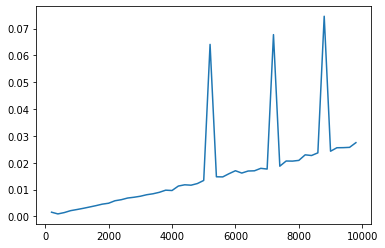

In [6]:
import matplotlib.pyplot as plt
times_2 = []
n_vertices_list = range(200, 10000, 200)
for n in n_vertices_list:
    t = timer()
    Ti = nx.random_tree(n)
    times_2.append(timer()-t)
fig, ax = plt.subplots(1)
ax.plot(n_vertices_list, times_2)

MST trees

In [8]:
n_vertices_list = [i for i in range(200, 1200, 200)]+[j for j in range(1500, 10500, 500)]
len(n_vertices_list)

23

0:0.055611875002796296
1:0.20455512499756878
2:0.4819687920025899
3:0.8819459579972317
4:1.387382583001454
5:3.253591125001549
6:5.919270874997892
7:9.05035987500014
8:12.827376332999847
9:18.63808049999352
10:23.21435704099713
11:30.033666916002403
12:38.834384166002565
13:47.165091000002576
14:67.33632245899935
15:72.5598030839974
16:94.51844037500268
17:133.29398966699955
18:161.9369641250014
19:614.2356507079967
20:811.3051107499996
21:1298.7069959579967
22:1494.6535123330104


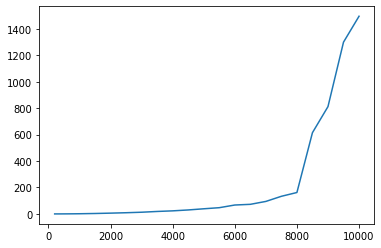

In [9]:
import matplotlib.pyplot as plt
times_3 = []
for i, n in enumerate(n_vertices_list):
    t = timer()
    Ti = random_mst_tree(n)
    t = timer()-t
    times_3.append(t)
    print("{}:{}".format(i,t))
fig, ax = plt.subplots(1)
ax.plot(n_vertices_list, times_3)

In [10]:
Ti = None

In [11]:
fig.savefig("MST_computation_time.pdf")